In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
# !pip install -e SPICE

In [3]:
import sys

import torch

from spice import SpiceEstimator

sys.path.append("../../..")
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from weinhardt2026.studies.castro2025.benchmarking_castro2025 import Castro2025Model, get_dataset, generate_behavior
import spice_castro2025, weinhardt2026.studies.castro2025.spice_castro2025 as spice_castro2025

# NOTEBOOK CONFIG

In [4]:
train_spice = False
train_cfs = False
train_gru = False

## Load dataset

In [ ]:
path_data = 'data/eckstein2024.csv'
test_blocks = (2,)  # pick sessions that exist for all participants; adjust if needed
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_blocks=test_blocks, verbose=True)

Shape of dataset: torch.Size([4158, 150, 1, 13])
Number of participants: 862
Number of actions in dataset: 4


In [6]:
# from spice import SpiceDataset

# # keep only 100 timesteps
# dataset_train = SpiceDataset(dataset_train.xs[:, :100], dataset_train.ys[:, :100])

# # keep only 100 participants for rapid prototyping
# keep_participants = torch.arange(0, 50)

# def keep_subset(dataset, subset):
#     participant_ids = dataset.xs[:, 0, 0, -1]
#     mask = torch.isin(participant_ids, subset)
#     return SpiceDataset(dataset.xs[mask], dataset.ys[mask])

# dataset_train = keep_subset(dataset_train, keep_participants)
# dataset_test = keep_subset(dataset_test, keep_participants)    


## SPICE Setup

## SPICE Training

Let's setup now the `SpiceEstimator` object and fit it to the data! 

We are going to do this in two steps:

1. Without fitting the SINDy coefficients to get the pure RNN performance given the selected architecture. 
2. With fitting SINDy coefficients to get the final performance of the interpretable model

That way we can disentangle the gap between GRU and SPICE w.r.t. architecture and SINDy library 

In [7]:
path_spice = 'params/spice_castro2025_62_stage1.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=spice_castro2025.SpiceModel,
        spice_config=spice_castro2025.CONFIG,
        n_actions=dataset_train.n_actions,
        n_participants=dataset_train.n_participants,
        
        epochs=1000,
        warmup_steps=250,

        verbose=True,
        # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        save_path_spice=path_spice,
    )

In [8]:
if train_spice:
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [9]:
# estimator.load_spice(path_spice)
# estimator.aggregate_coefficients()

In [10]:
# Print example SPICE model for first participant
print("\nExample SPICE model (participant 0):")
# estimator.print_spice_model(participant_id=0)


Example SPICE model (participant 0):


## Benchmarking

### Castro2025 benchmark model

In [11]:
path_spice = 'params/spice_castro2025.pkl'

# Benchmark model: Castro et al. 2025
cfs = Castro2025Model(
    n_participants=862,#dataset_train.n_participants,
    n_actions=dataset_train.n_actions,
    batch_first=True,
    )

path_cfs = path_spice.replace('spice_', 'cfs_')

In [12]:
if train_cfs:
    optimizer_cfs = torch.optim.Adam(params=cfs.parameters(), lr=0.01)
    epochs = 1000

    cfs = training(
        model=cfs,
        optimizer=optimizer_cfs,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        loss_kwargs={'label_smoothing': 0.0},
    )

    torch.save(cfs.state_dict(), path_cfs)

In [13]:
cfs.load_state_dict(torch.load(path_cfs, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [14]:
gru = GRUModel(
    n_actions=dataset_train.n_actions, 
    additional_inputs=2, 
    dropout=0.1,
    hidden_size=32,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [15]:
if train_gru:
    epochs = 1000
    optimizer_gru = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru,
        optimizer=optimizer_gru,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        loss_kwargs={'label_smoothing': 0.0},
        ).to(torch.device('cpu'))

    torch.save(gru.state_dict(), path_gru)

In [16]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

<All keys matched successfully>

# ANALYSIS

In [17]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from analysis_generative import analysis_generative_behavior

In [18]:
# estimator.eval()
cfs.eval()
gru.eval()

GRUModel(
  (participant_embedding): Embedding(1, 16)
  (experiment_embedding): Embedding(1, 16)
  (linear_in): Linear(in_features=10, out_features=32, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (gru): GRU(32, 32, batch_first=True)
  (linear_out): Linear(in_features=32, out_features=4, bias=True)
)

## General Analysis

In [19]:
# Dataset-specific behavioral analysis placeholder.
# Replace with Eckstein2024-specific columns if needed.

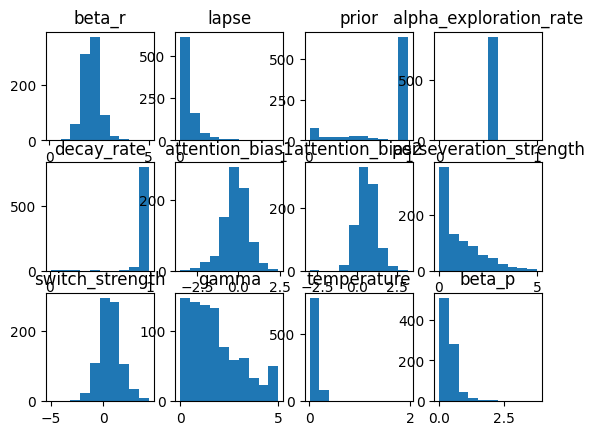

In [20]:
import matplotlib.pyplot as plt

list_parameters_cfs = [
    'beta_r', 
    'lapse', 
    'prior', 
    'alpha_exploration_rate', 
    'decay_rate', 
    'attention_bias1', 
    'attention_bias2', 
    'perseveration_strength', 
    'switch_strength', 
    'gamma', 
    'temperature', 
    'beta_p',
    ]
fig, axs = plt.subplots(3, 4)
for i in range(len(list_parameters_cfs)):
    row = i//4
    col = i%4
    axs[row, col].hist(getattr(cfs, list_parameters_cfs[i]).detach().cpu().numpy())
    axs[row, col].set_title(list_parameters_cfs[i])
plt.show()


## Analysis Model Evaluation

In [24]:
analysis_model_evaluation(
    dataset=dataset_train,
    spice_model=estimator,
    benchmark_model=cfs.to(torch.device('cpu')),
    gru_model=gru.eval().to(torch.device('cpu')),
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.621020,0.159128,13.0,0.0,232753.859375,4.655337e+05,465678.000
GRU,0.627344,0.156140,6852.0,0.0,227803.765625,4.693115e+05,545363.625
SPICE-RNN,0.227396,0.123089,16868.0,0.0,723612.062500,1.480960e+06,1668182.250
SPICE-SYM,0.249243,0.021921,76.0,0.0,678792.500000,1.357737e+06,1358580.500


In [25]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    benchmark_model=cfs.to(torch.device('cpu')),
    gru_model=gru.eval().to(torch.device('cpu')),
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.598384,0.161196,13.0,0.0,65651.343750,131328.687500,131455.546875
GRU,0.618730,0.157360,6852.0,0.0,61376.554688,136457.109375,203322.843750
SPICE-RNN,0.231579,0.123778,16868.0,0.0,187016.265625,407768.531250,572376.125000
SPICE-SYM,0.248325,0.021263,76.0,0.0,178090.484375,356332.968750,357074.625000


## Analysis generative behavior

In [26]:
estimator.use_sindy(True)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice.csv'
)

estimator.use_sindy(False)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice_rnn.csv'
)

gru.eval()
generate_behavior(
    model=gru,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_gru.csv'
)

generate_behavior(
    model=cfs,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_cfs.csv'
)

Generating behavior...


100%|██████████| 150/150 [00:06<00:00, 24.27it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 150/150 [00:04<00:00, 36.77it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 150/150 [00:00<00:00, 383.49it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 150/150 [00:00<00:00, 191.86it/s]


Done generating behavior.


Loading real from data/eckstein2024.csv...
Loading benchmark from data/eckstein2024_cfs.csv...
Loading gru from data/eckstein2024_gru.csv...
Loading spice_rnn from data/eckstein2024_spice_rnn.csv...
Loading spice from data/eckstein2024_spice.csv...
            Average Reward       Total Reward    P(Stay | Win)  \
Model                                                            
real       0.637 +/- 0.089  94.401 +/- 13.416  0.839 +/- 0.152   
benchmark  0.526 +/- 0.036   77.486 +/- 5.723  0.883 +/- 0.126   
gru        0.630 +/- 0.039   92.727 +/- 6.256  0.914 +/- 0.085   
spice_rnn  0.522 +/- 0.014   76.883 +/- 2.817  0.278 +/- 0.086   
spice      0.511 +/- 0.011   75.278 +/- 2.498  0.250 +/- 0.049   

            P(Stay | Loss)          P(Stay)  
Model                                        
real       0.280 +/- 0.268  0.760 +/- 0.160  
benchmark  0.484 +/- 0.241  0.724 +/- 0.156  
gru        0.393 +/- 0.253  0.840 +/- 0.105  
spice_rnn  0.289 +/- 0.107  0.286 +/- 0.085  
spice      0

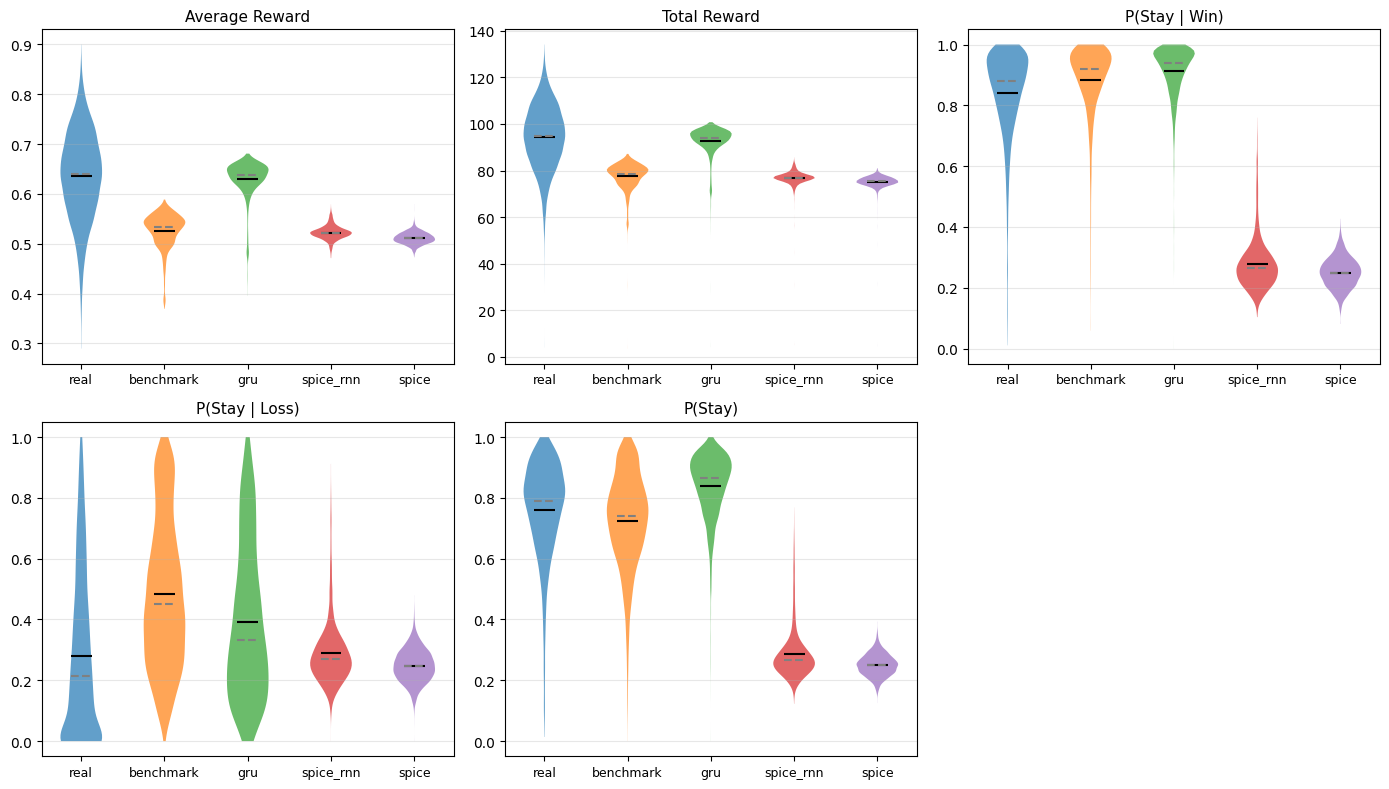


Normalized MAE (|model_mean - real_mean| / real_std):
          Average Reward Total Reward P(Stay | Win) P(Stay | Loss) P(Stay)  \
Model                                                                        
benchmark         1.2462       1.2608        0.2912         0.7622  0.2261   
gru               0.0780       0.1248        0.4975         0.4221  0.4973   
spice_rnn         1.2908       1.3058        3.7006         0.0349  2.9555   
spice             1.4138       1.4254        3.8852         0.1193  3.1793   

              Aggregate NMAE  
Model                         
benchmark  0.7573 +/- 0.4454  
gru        0.3240 +/- 0.1844  
spice_rnn  1.8575 +/- 1.3077  
spice      2.0046 +/- 1.3532  


(            Average Reward       Total Reward    P(Stay | Win)  \
 Model                                                            
 real       0.637 +/- 0.089  94.401 +/- 13.416  0.839 +/- 0.152   
 benchmark  0.526 +/- 0.036   77.486 +/- 5.723  0.883 +/- 0.126   
 gru        0.630 +/- 0.039   92.727 +/- 6.256  0.914 +/- 0.085   
 spice_rnn  0.522 +/- 0.014   76.883 +/- 2.817  0.278 +/- 0.086   
 spice      0.511 +/- 0.011   75.278 +/- 2.498  0.250 +/- 0.049   
 
             P(Stay | Loss)          P(Stay)  
 Model                                        
 real       0.280 +/- 0.268  0.760 +/- 0.160  
 benchmark  0.484 +/- 0.241  0.724 +/- 0.156  
 gru        0.393 +/- 0.253  0.840 +/- 0.105  
 spice_rnn  0.289 +/- 0.107  0.286 +/- 0.085  
 spice      0.248 +/- 0.053  0.250 +/- 0.036  ,
           Average Reward Total Reward P(Stay | Win) P(Stay | Loss) P(Stay)  \
 Model                                                                        
 benchmark         1.2462       1.2608   

In [27]:
analysis_generative_behavior(
    path_data_real=path_data,
    path_data_gru='data/eckstein2024_gru.csv',
    path_data_benchmark='data/eckstein2024_cfs.csv',
    path_data_spice='data/eckstein2024_spice.csv',
    path_data_spice_rnn='data/eckstein2024_spice_rnn.csv',
    output_dir='results',
)

## Analysis coefficient distributions

In [28]:
# analysis_coefficients_distributions(
#     spice_model=estimator,
#     output_dir='results',
# )

## Analysis Individual Differences

In [29]:
# analysis_coefficients_individuals(
#     criterion="SomeCriterionColumnInYourDataset",
#     analysis="disc",  # also: "cont"
#     reference="ReferenceGroupFromCriterionColumn",  # only necessary if analysis="disc"
    
#     path_data=path_file,
    
#     spice_model=estimator,
    
#     dir_output='results',
# )